# Chapter 4 — Introduction to Neural Learning: Gradient Descent

## Learning Objectives

This notebook covers prediction error, mean squared error, hot-and-cold learning, gradient descent, delta, weight_delta, alpha, divergence, and learning-rate control.

## Theoretical Explanation

Learning begins by comparing a prediction to a target. Mean squared error makes errors positive and emphasizes large mistakes. Gradient descent improves on trial-and-error learning by computing both the direction and approximate amount to change a weight. The core update is based on `delta = prediction - target` and `weight_delta = input * delta`.

The learning rate `alpha` controls how much of the update is applied. If alpha is too high, updates can overshoot and diverge. If alpha is too low, learning becomes slow.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Gradient Descent for One Weight

   iteration     error  prediction    weight
0          0  0.302500    0.250000  0.775000
1          1  0.170156    0.387500  0.981250
2          2  0.095713    0.490625  1.135938
3          3  0.053839    0.567969  1.251953
4          4  0.030284    0.625977  1.338965
Final prediction: 0.7994481347973457


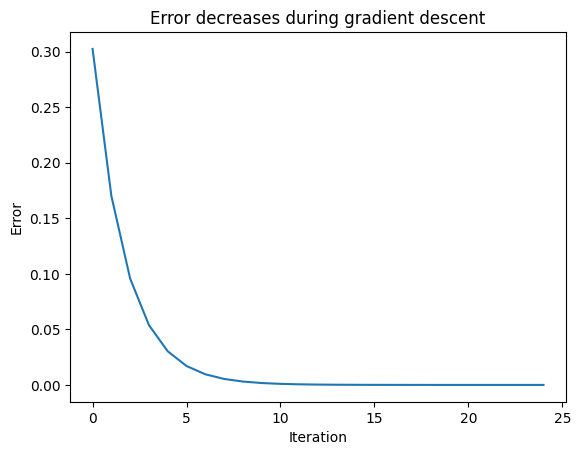

In [2]:
weight = 0.5
input_value = 0.5
target = 0.8
history = []
for iteration in range(25):
    pred = input_value * weight
    error = (pred - target) ** 2
    delta = pred - target
    weight_delta = input_value * delta
    weight -= weight_delta
    history.append((iteration, error, pred, weight))

print(pd.DataFrame(history, columns=['iteration','error','prediction','weight']).head())
print('Final prediction:', history[-1][2])
plt.plot([h[1] for h in history])
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.title('Error decreases during gradient descent')
plt.show()

### Output Interpretation

The error decreases as the weight is updated. The derivative-like value `weight_delta` tells the model how the weight should move to reduce error.

## 2. Alpha Prevents Divergence

alpha: 0.01 last error: 0.016294
alpha: 0.1 last error: 1e-06
alpha: 0.8 last error: 1365711.509457


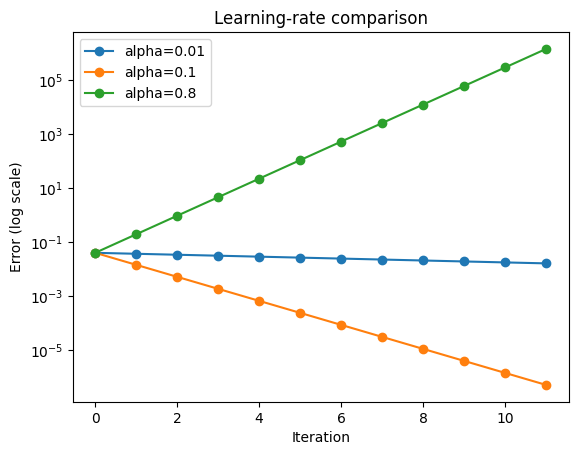

In [3]:
def train(alpha, input_value=2.0, target=0.8, weight=0.5, steps=12):
    errors = []
    for _ in range(steps):
        pred = input_value * weight
        error = (pred - target)**2
        delta = pred - target
        weight_delta = input_value * delta
        weight -= alpha * weight_delta
        errors.append(error)
    return errors

for alpha in [0.01, 0.1, 0.8]:
    errors = train(alpha)
    print('alpha:', alpha, 'last error:', round(errors[-1], 6))
    plt.plot(errors, marker='o', label=f'alpha={alpha}')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Error (log scale)')
plt.title('Learning-rate comparison')
plt.legend()
plt.show()

### Output Interpretation

A moderate alpha reduces error efficiently. Too large an alpha can cause unstable behavior, while too small an alpha learns slowly.

## Extended Study Notes

The main learning style in this notebook is intentionally close to the book's philosophy: build the idea from small numerical operations, inspect the output, and then connect the output back to the deep learning concept. Instead of treating a neural network as a black box, each notebook exposes the role of inputs, weights, predictions, error, deltas, gradients, and updates.

The examples are original/adapted demonstrations written for academic learning. They preserve the conceptual workflow of the reference book while avoiding direct copying of long code listings. This is important for academic integrity and also makes the notebooks easier to understand as independent study material.

## Chapter Summary

This chapter was reproduced as a compact but complete study notebook. It combines conceptual explanation, NumPy-based implementation, output interpretation, and practical deep learning context.

## Key Takeaways

- Neural networks are built from repeated numerical operations on vectors, matrices, and tensors.
- Learning means changing weights so predictions produce smaller error.
- Shape consistency and interpretation of intermediate values are essential for debugging.
- Understanding the from-scratch implementation makes high-level frameworks easier to use responsibly.